In [1]:
import numpy as np
from numpy.random import normal
import matplotlib.pyplot as plt

$$dx^i=A^i(x)d\tau+B^i_a(x)dW^a$$

$$i=1,...,var dim$$
$$a=1,..,noise dim$$

In [2]:
from qgravity import (
    EulerMaruyama,
    ItoSolver,
    OrnsteinUhlenbeck,
    QuadraticGravity,
)

In [2]:
from abc import ABC, abstractmethod

class Ito_equation(ABC):
    
    def __init__(self,var_dim=1,noise_dim=1):

        self.var_dim = var_dim
        self.noise_dim = noise_dim
    
    @abstractmethod
    def drift_vector(self,x):
        raise NotImplementedError
    
    @abstractmethod
    def diffusion_matrix(self,x):
        raise NotImplementedError

    def shape_check(self):
        x = np.zeros((self.var_dim,))
        
        if self.drift_vector(x).shape != (self.var_dim,):
            raise ValueError("Incorrect shape of drift")

        if self.diffusion_matrix(x).shape != (self.var_dim,self.noise_dim):
            raise ValueError("Incorrect shape of diffusion")      


In [3]:
class Scheme(ABC):
    

    @abstractmethod
    def step(self,equation,dt,rng,x):
        raise NotImplementedError  




    

In [ ]:
class Euler(Scheme):
    
    def __init__(self):
        pass


    def step(self,equation,dt,rng,x):
        dW = np.sqrt(dt) * rng.standard_normal(size = equation.noise_dim)

        drift = equation.drift_vector(x) * dt
        noise = equation.diffusion_matrix(x) @ dW

        return x + drift + noise       

In [ ]:
class Ito_solver:
    
    def __init__(self,equation,scheme,time_step,total_time,rng=None):


        self.eq = equation
        self.scheme = scheme
        
        self.total_time = total_time
        self.time_step = time_step


        self.N_steps = int(round(total_time/time_step))
        self.tau_grid = time_step * np.arange(0,self.N_steps+1)

        if rng is None:
            rng = np.random.default_rng()

        self.rng = rng

        self.eq.shape_check()    


         
        
    
    
    def solve_one_process(self,initial_cond):


        x = np.asarray(initial_cond,dtype=float).copy()
        self.initial_cond_check(x)

        traj = np.zeros((self.N_steps+1, self.eq.var_dim)) 

        traj[0,:] = x
        
        for k in range(1,self.N_steps+1):
            x = self.scheme.step(self.eq,self.time_step,self.rng,x)
            traj[k,:] = x

        return traj 


    def initial_cond_check(self,x):
        if x.shape != (self.eq.var_dim,):
            raise ValueError("Incorrect shape of initial condition")



In [ ]:
class Quadratic_gravity(Ito_equation):
    def __init__(self,sigma,nu):
        super().__init__(3,1)
        self.sigma = sigma
        self.nu = nu
    
    def drift_vector(self,x):
        a_beta = x[0] ** 2 - self.nu * x[1] ** 2
        a_alpha = x[0] * x[1]
        a_g = x[1]
        return np.array([a_beta,a_alpha,a_g])
    
    def diffusion_matrix(self,x):
        b_arr = np.zeros((3,1))
        b_arr[0][0] = self.sigma 
        return b_arr 

            

In [7]:
qg = Quadratic_gravity(0,1)
qg_solver = Ito_solver(qg,Euler,0.0001,1,1) 

In [8]:
qg_solver.solve(np.array([1.0,1.0,0.0]))

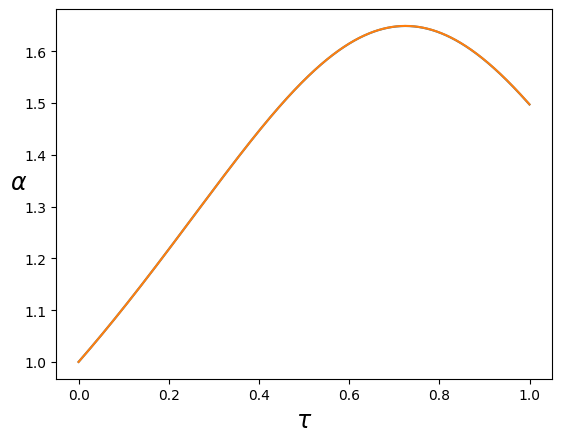

In [9]:
plt.figure()
g = qg_solver.result[0,:,2]
alpha = qg_solver.result[0,:,1]
beta = qg_solver.result[0,:,0] 
plt.plot(qg_solver.tau_grid,np.exp(g-1/2 * g**2))
plt.plot(qg_solver.tau_grid,alpha)
plt.xlabel(r'$\tau$',fontsize=17)
plt.ylabel(r'$\alpha$',fontsize=17,rotation=0)    
plt.show()

In [77]:
np.save("g",g)
np.save("alpha",alpha)
np.save("tau_grid",qg_solver.tau_grid)

In [ ]:
"""
class Ornstein_Ulenbek(Ito_equation):
    def __init__(self,alpha,beta,sigma):
        self.alpha = alpha
        self.beta = beta 
        self.sigma = sigma 
        
        super().__init__(1,1)

    def drift_vector(self,x):
        a_arr = np.zeros((1)) 
        a_arr = -self.beta * (x-self.alpha)
        return a_arr
    
    def diffusion_matrix(self,x):
        b_arr = np.zeros((1,1))
        b_arr[0][0] = self.sigma
        return b_arr
"""        

''

In [ ]:
"""
orn = Ornstein_Ulenbek(0,1,1)
orn_solver = Ito_solver(orn,Euler,0.0001,10,10)
"""    

NameError: name 'Ornstein_Ulenbek' is not defined

In [ ]:
"""orn_solver.solve(np.array([1.0]))"""


In [ ]:
"""
plt.figure()
for s in range(orn_solver.N_samples):
    plt.plot(orn_solver.time_grid,orn_solver.result[s,:,0])
plt.show()
"""

NameError: name 'plt' is not defined